<a href="https://colab.research.google.com/github/jawariyakhawer/Transfer-learning-project/blob/main/Transfer_learning_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Load dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2569s 15us/step
Training Images: (50000, 32, 32, 3)
Testing Images: (10000, 32, 32, 3)


In [ ]:
from tensorflow.keras.datasets import cifar10

# Load dataset to ensure x_train, y_train, x_test, y_test are defined
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train[:5000]
y_train = y_train[:5000]

x_test = x_test[:1000]
y_test = y_test[:1000]

In [ ]:
import tensorflow as tf

# Resize images and normalize

x_train = tf.image.resize(x_train, (224, 224)) / 255.0
x_test = tf.image.resize(x_test, (224, 224)) / 255.0

print(x_train.shape)
print(x_test.shape)

(5000, 224, 224, 3)
(1000, 224, 224, 3)


In [ ]:
from tensorflow.keras.applications import VGG16

# Load VGG16 model
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze VGG16 layers
base_model.trainable = False

print("VGG16 Loaded Successfully!")

VGG16 Loaded Successfully!


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=16,
    validation_data=(x_test, y_test)
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 51s 134ms/step - accuracy: 0.2194 - loss: 2.1162 - val_accuracy: 0.3070 - val_loss: 1.8828
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.3374 - loss: 1.8178 - val_accuracy: 0.4150 - val_loss: 1.6930
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.3990 - loss: 1.6911 - val_accuracy: 0.4590 - val_loss: 1.5778
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 117ms/step - accuracy: 0.4066 - loss: 1.6365 - val_accuracy: 0.4600 - val_loss: 1.5347
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 37s 118ms/step - accuracy: 0.4354 - loss: 1.5734 - val_accuracy: 0.4770 - val_loss: 1.4684


In [ ]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 156ms/step - accuracy: 0.4770 - loss: 1.4684
Test Loss: 1.46844482421875
Test Accuracy: 0.47699999809265137


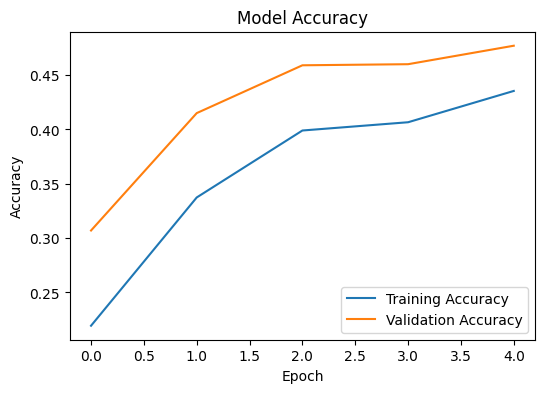

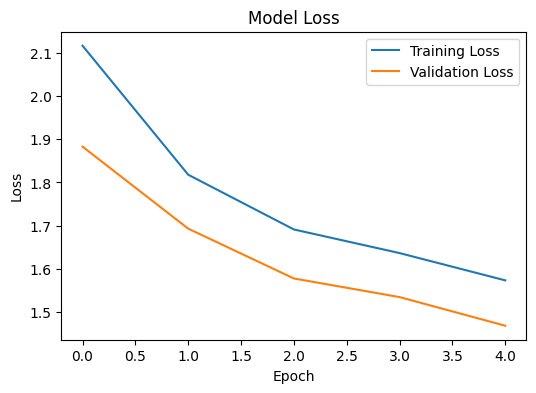

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()